# New Video Model Inference and Rollout

This notebook compares the two new video-style models:

- LTX-VICON: `LTXViconVideoModel`
- Pretrained VICON transformer video adapter: `ViconTransformerVideoModel`

It runs single-step inference and autoregressive rollout on PDEArena incompressible samples. Defaults point at the completed 100k-step runs discovered in `logs/train/runs`, and can be overridden with environment variables:

- `LTX_VICON_CKPT_PATH`
- `VICON_TRANSFORMER_VIDEO_CKPT_PATH`
- `VIDEO_MODEL_SAMPLE_IDX`
- `VIDEO_MODEL_ROLLOUT_STEPS`

In [3]:
from pathlib import Path
import os
import re
import sys

import hydra
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

repo_root = next(
    candidate for candidate in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (candidate / 'src' / 'train.py').exists()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from src.datasets.pdearena.pdearena_incomp_split import PDEArenaIncompSplitDataset

print(f'repo root: {repo_root}')

repo root: /home/griffing52/ucla/math270a/icon-core


In [4]:
def move_to_device(value, device: torch.device):
    if isinstance(value, torch.Tensor):
        return value.to(device)
    if isinstance(value, dict):
        return {key: move_to_device(item, device) for key, item in value.items()}
    return value


def to_frame(tensor: torch.Tensor) -> torch.Tensor:
    tensor = tensor.detach().cpu()
    while tensor.ndim > 3:
        tensor = tensor[0]
    if tensor.ndim != 3:
        raise ValueError(f'Expected a frame shaped [C, H, W], got {tuple(tensor.shape)}')
    return tensor


def field_maps(frame: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    if frame.shape[0] == 7:
        u_comp = frame[1]
        v_comp = frame[2]
    elif frame.shape[0] == 2:
        u_comp = frame[0]
        v_comp = frame[1]
    else:
        raise ValueError(f'Expected 2 or 7 channels, got {frame.shape[0]}')
    speed = torch.linalg.norm(torch.stack([u_comp, v_comp], dim=0), dim=0)
    return speed, u_comp, v_comp


def frame_mae(pred_frame: torch.Tensor, target_frame: torch.Tensor) -> torch.Tensor:
    return (pred_frame - target_frame).abs().flatten().mean()


def component_maes(pred_frame: torch.Tensor, target_frame: torch.Tensor):
    pred_speed, pred_u, pred_v = field_maps(pred_frame)
    gt_speed, gt_u, gt_v = field_maps(target_frame)
    return (
        (pred_speed - gt_speed).abs().mean(),
        (pred_u - gt_u).abs().mean(),
        (pred_v - gt_v).abs().mean(),
    )


def component_rrmses(pred_frame: torch.Tensor, target_frame: torch.Tensor):
    pred_speed, pred_u, pred_v = field_maps(pred_frame)
    gt_speed, gt_u, gt_v = field_maps(target_frame)

    def rrmse(pred, gt):
        rmse = torch.sqrt(((pred - gt) ** 2).mean())
        rms_gt = torch.sqrt((gt ** 2).mean())
        return rmse / (rms_gt + 1e-8)

    return rrmse(pred_speed, gt_speed), rrmse(pred_u, gt_u), rrmse(pred_v, gt_v)


def set_panel(axis, image: torch.Tensor, title: str, vmin: float, vmax: float, cmap: str) -> None:
    handle = axis.imshow(image.numpy(), origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
    axis.set_title(title)
    axis.set_xticks([])
    axis.set_yticks([])
    plt.colorbar(handle, ax=axis, fraction=0.046, pad=0.04)

In [5]:
def checkpoint_step(path: Path) -> int:
    match = re.search(r'step_(\d+)\.ckpt$', path.name)
    return int(match.group(1)) if match else -1


def latest_checkpoint_in_run(run_dir: Path) -> Path | None:
    checkpoint_dir = run_dir / 'checkpoints'
    candidates = sorted(checkpoint_dir.glob('step_*.ckpt'), key=checkpoint_step)
    if candidates:
        return candidates[-1]
    last_ckpt = checkpoint_dir / 'last.ckpt'
    return last_ckpt if last_ckpt.exists() else None


def resolve_checkpoint(env_var: str, preferred_run: str, target_text: str) -> Path:
    env_path = os.environ.get(env_var)
    if env_path:
        return Path(env_path).expanduser().resolve()

    preferred = repo_root / 'logs' / 'train' / 'runs' / preferred_run / 'checkpoints' / 'step_100000.ckpt'
    if preferred.exists():
        return preferred

    run_root = repo_root / 'logs' / 'train' / 'runs'
    matching_runs = []
    for run_dir in sorted(run_root.glob('*')):
        if not run_dir.is_dir():
            continue
        metadata_paths = [
            run_dir / '.hydra' / 'config.yaml',
            run_dir / 'csv' / 'version_0' / 'hparams.yaml',
        ]
        metadata = '\n'.join(path.read_text(errors='ignore') for path in metadata_paths if path.exists())
        if target_text in metadata:
            checkpoint = latest_checkpoint_in_run(run_dir)
            if checkpoint is not None:
                matching_runs.append(checkpoint)

    if matching_runs:
        return sorted(matching_runs, key=lambda item: (checkpoint_step(item), item.stat().st_mtime), reverse=True)[0]

    raise FileNotFoundError(f'No checkpoint found for {target_text}. Set {env_var}.')


def load_model_from_checkpoint(checkpoint_path: Path):
    checkpoint_path = Path(checkpoint_path).expanduser().resolve()
    run_dir = checkpoint_path.parents[1]
    config_path = run_dir / '.hydra' / 'config.yaml'
    if not config_path.exists():
        raise FileNotFoundError(f'Expected run config at {config_path}')

    cfg = OmegaConf.load(config_path)
    OmegaConf.set_struct(cfg, False)
    cfg.paths.root_dir = str(repo_root)
    cfg.paths.data_dir = str(repo_root / 'data')

    model = hydra.utils.instantiate(cfg.model).to(device).eval()
    checkpoint = torch.load(checkpoint_path, map_location='cpu', weights_only=False)
    state_dict = checkpoint.get('state_dict', checkpoint)
    net_state = {
        key.removeprefix('net.'): value
        for key, value in state_dict.items()
        if key.startswith('net.')
    }
    if not net_state:
        net_state = state_dict
    missing, unexpected = model.load_state_dict(net_state, strict=False)
    if missing or unexpected:
        print('load_state_dict warnings')
        print('  missing:', missing[:10], '...' if len(missing) > 10 else '')
        print('  unexpected:', unexpected[:10], '...' if len(unexpected) > 10 else '')
    model.to(device).eval()
    return model, checkpoint, cfg

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sample_idx = int(os.environ.get('VIDEO_MODEL_SAMPLE_IDX', 0))
data_glob = repo_root / 'data' / 'pdearena_incomp' / 'ns_incom_inhom_2d_512-*.h5'

dataset = PDEArenaIncompSplitDataset(file_paths=str(data_glob), ex_num=5, split='train')
sample = move_to_device(dataset[sample_idx], device)

ltx_ckpt_path = resolve_checkpoint(
    env_var='LTX_VICON_CKPT_PATH',
    preferred_run='2026-06-04_09-22-45-350017',
    target_text='src.models.vicon.ltx_vicon.LTXViconVideoModel',
)
vicon_video_ckpt_path = resolve_checkpoint(
    env_var='VICON_TRANSFORMER_VIDEO_CKPT_PATH',
    preferred_run='2026-06-04_09-17-31-328733',
    target_text='src.models.vicon.vicon_transformer_video.ViconTransformerVideoModel',
)

ltx_model, ltx_checkpoint, ltx_cfg = load_model_from_checkpoint(ltx_ckpt_path)
vicon_video_model, vicon_video_checkpoint, vicon_video_cfg = load_model_from_checkpoint(vicon_video_ckpt_path)

with torch.no_grad():
    ltx_pred = ltx_model.predict_backbone(sample['data'], mode='test', need_weights=False)['qn_pred']
    vicon_video_pred = vicon_video_model.predict_backbone(sample['data'], mode='test', need_weights=False)['qn_pred']

gt_frame = to_frame(sample['label'])
input_frame = to_frame(sample['data']['qn_f'])
ltx_frame = to_frame(ltx_pred)
vicon_video_frame = to_frame(vicon_video_pred)

print(f'device: {device}')
print(f'sample index: {sample_idx}')
print(f'LTX checkpoint: {ltx_ckpt_path}')
print(f'LTX global step: {ltx_checkpoint.get("global_step")}')
print(f'VICON-transformer checkpoint: {vicon_video_ckpt_path}')
print(f'VICON-transformer global step: {vicon_video_checkpoint.get("global_step")}')
print(f'input shape: {tuple(input_frame.shape)}')
print(f'LTX prediction shape: {tuple(ltx_frame.shape)}')
print(f'VICON-transformer prediction shape: {tuple(vicon_video_frame.shape)}')
print(f'target shape: {tuple(gt_frame.shape)}')

/home/griffing52/ucla/math270a/icon-core/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
/home/griffing52/ucla/math270a/icon-core/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Loading checkpoint shards: 100%|██████████| 2/2 [00:08<00:00,  4.27s/it]


device: cuda
sample index: 0
LTX checkpoint: /home/griffing52/ucla/math270a/icon-core/logs/train/runs/2026-06-04_09-22-45-350017/checkpoints/step_100000.ckpt
LTX global step: 100000
VICON-transformer checkpoint: /home/griffing52/ucla/math270a/icon-core/logs/train/runs/2026-06-04_09-17-31-328733/checkpoints/step_100000.ckpt
VICON-transformer global step: 100000
input shape: (2, 512, 512)
LTX prediction shape: (2, 512, 512)
VICON-transformer prediction shape: (2, 512, 512)
target shape: (2, 512, 512)


Single-step MAE vs ground truth
  LTX-VICON: 0.388026
  VICON transformer video: 0.057594


Text(0.5, 0.98, 'Single-step prediction')

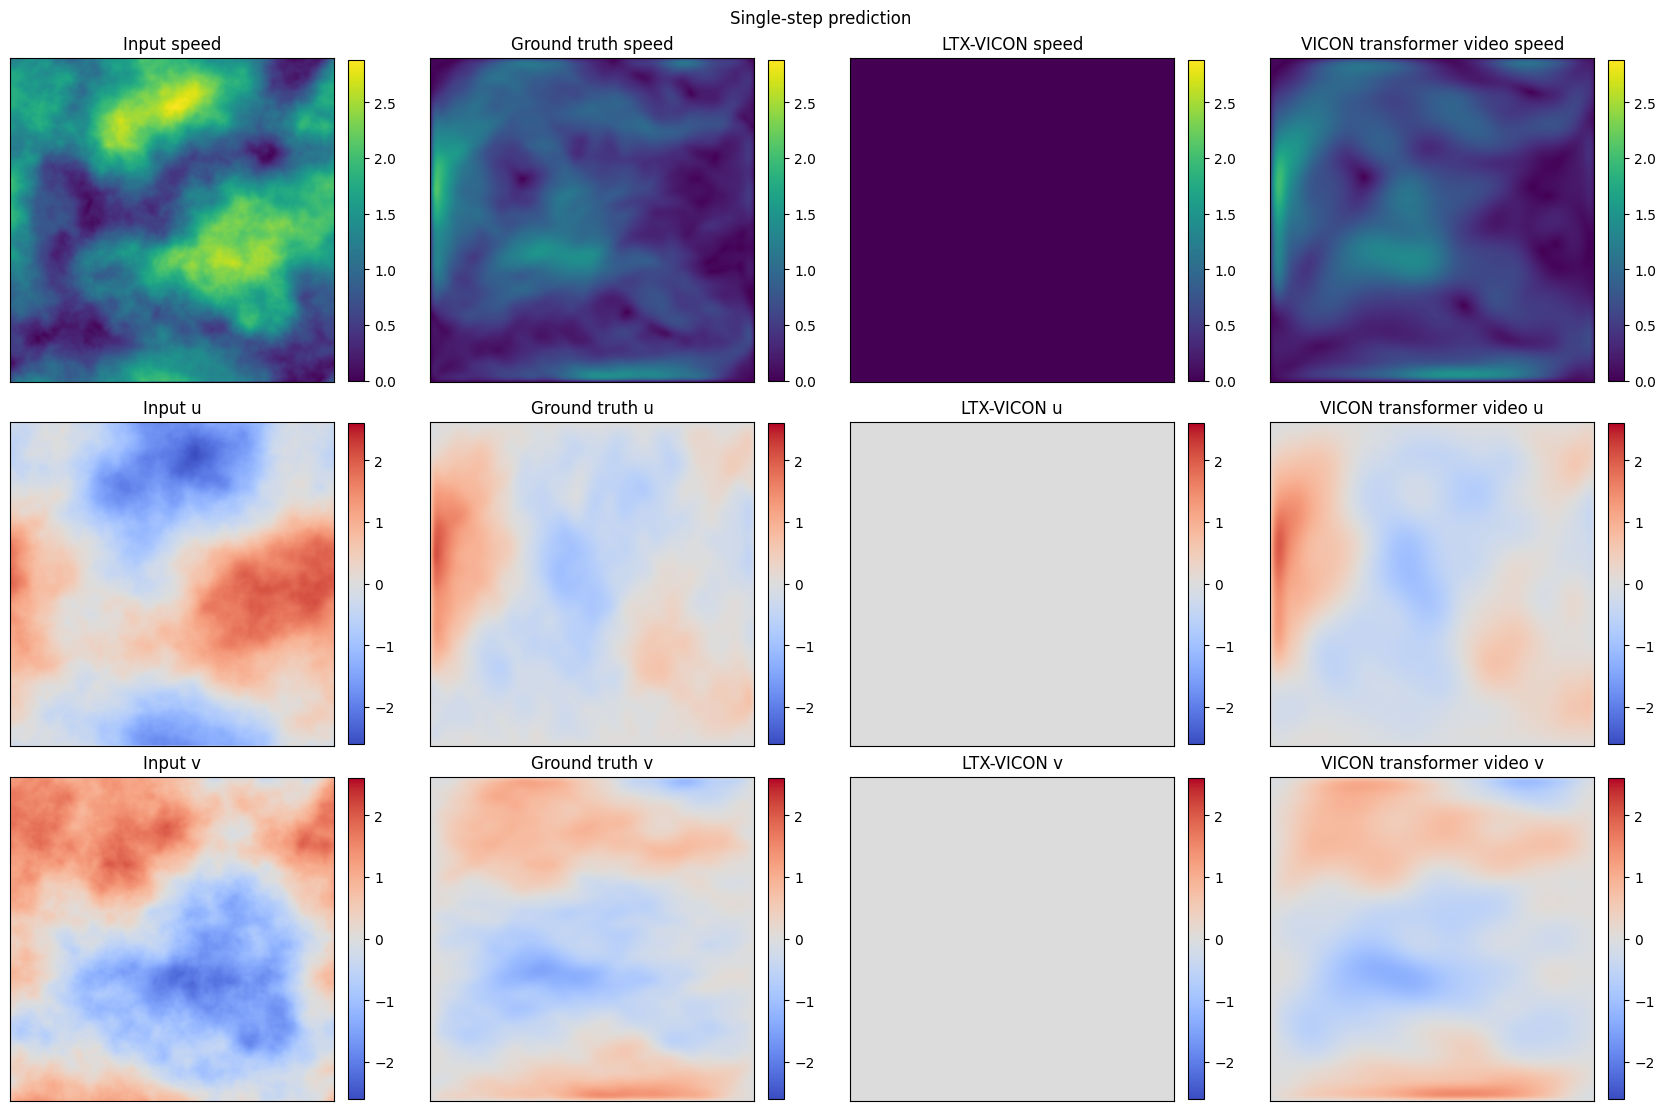

In [7]:
print('Single-step MAE vs ground truth')
print(f'  LTX-VICON: {frame_mae(ltx_frame, gt_frame).item():.6f}')
print(f'  VICON transformer video: {frame_mae(vicon_video_frame, gt_frame).item():.6f}')

models = [
    ('Input', input_frame),
    ('Ground truth', gt_frame),
    ('LTX-VICON', ltx_frame),
    ('VICON transformer video', vicon_video_frame),
]

speed_stack = torch.stack([field_maps(frame)[0] for _, frame in models])
component_stack = torch.stack([field_maps(frame)[idx] for _, frame in models for idx in (1, 2)])
speed_vmax = speed_stack.max().item()
component_vmax = component_stack.abs().max().item()

fig, axes = plt.subplots(3, len(models), figsize=(4.2 * len(models), 11), constrained_layout=True)
for col, (name, frame) in enumerate(models):
    speed, u_comp, v_comp = field_maps(frame)
    set_panel(axes[0, col], speed, f'{name} speed', 0, speed_vmax, 'viridis')
    set_panel(axes[1, col], u_comp, f'{name} u', -component_vmax, component_vmax, 'coolwarm')
    set_panel(axes[2, col], v_comp, f'{name} v', -component_vmax, component_vmax, 'coolwarm')
fig.suptitle('Single-step prediction')

## Autoregressive Rollout

Each model gets the same fixed example prompt. At every rollout step, only `qn_f` is replaced with that model's previous prediction.

In [8]:
rollout_steps_requested = int(os.environ.get('VIDEO_MODEL_ROLLOUT_STEPS', 6))

qn_traj_idx, rollout_start_time = dataset._samples[sample_idx]
max_rollout_steps = (dataset._time_steps - 1 - rollout_start_time) // dataset.target_time_offset
rollout_steps = max(1, min(rollout_steps_requested, max_rollout_steps))
rollout_ref = dataset._split_refs[qn_traj_idx]
rollout_sample = move_to_device(dataset[sample_idx], device)
rollout_base_data = {
    'ex_f': rollout_sample['data']['ex_f'],
    'ex_g': rollout_sample['data']['ex_g'],
}


def read_rollout_frame(step: int) -> torch.Tensor:
    time_idx = rollout_start_time + step * dataset.target_time_offset
    frame = dataset._read_velocity_frame(rollout_ref, time_idx)
    return frame.unsqueeze(0).unsqueeze(0)


def rollout_model(model, initial_qn_f: torch.Tensor) -> list[torch.Tensor]:
    current = initial_qn_f
    frames = []
    for _ in range(rollout_steps):
        data_step = {**rollout_base_data, 'qn_f': current}
        with torch.no_grad():
            next_frame = model.predict_backbone(data_step, mode='test', need_weights=False)['qn_pred']
        frames.append(to_frame(next_frame))
        current = next_frame
    return frames


initial_qn_f = read_rollout_frame(0).to(device)
gt_rollout_frames = [to_frame(read_rollout_frame(step)) for step in range(1, rollout_steps + 1)]
ltx_rollout_frames = rollout_model(ltx_model, initial_qn_f)
vicon_video_rollout_frames = rollout_model(vicon_video_model, initial_qn_f)

ltx_rollout_mae = torch.tensor([
    frame_mae(pred, target).item()
    for pred, target in zip(ltx_rollout_frames, gt_rollout_frames, strict=True)
])
vicon_video_rollout_mae = torch.tensor([
    frame_mae(pred, target).item()
    for pred, target in zip(vicon_video_rollout_frames, gt_rollout_frames, strict=True)
])

print(f'rollout sample index: {sample_idx}')
print(f'rollout query trajectory index: {qn_traj_idx}')
print(f'rollout start time: {rollout_start_time}')
print(f'rollout steps requested: {rollout_steps_requested}')
print(f'rollout steps used: {rollout_steps}')
print('per-step MAE LTX-VICON:', [round(value, 6) for value in ltx_rollout_mae.tolist()])
print('per-step MAE VICON transformer video:', [round(value, 6) for value in vicon_video_rollout_mae.tolist()])

rollout sample index: 0
rollout query trajectory index: 0
rollout start time: 0
rollout steps requested: 6
rollout steps used: 6
per-step MAE LTX-VICON: [0.388026, 0.378343, 0.370699, 0.364237, 0.358345, 0.353025]
per-step MAE VICON transformer video: [0.057594, 0.095026, 0.134877, 0.172551, 0.210263, 0.245512]


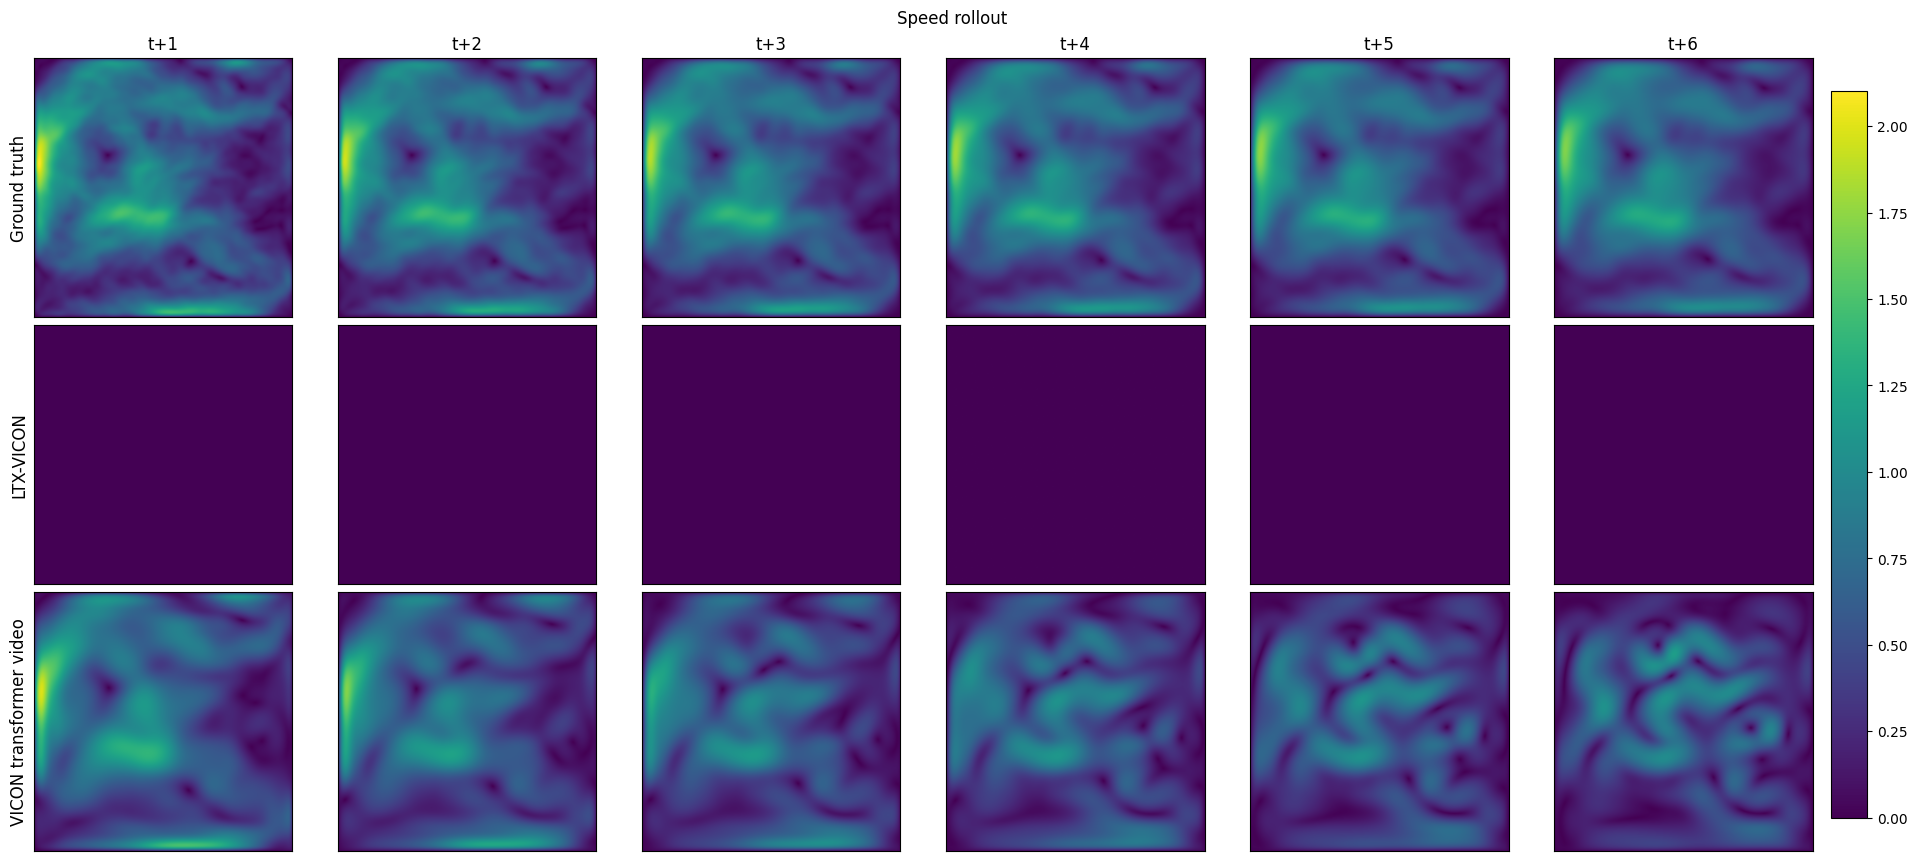

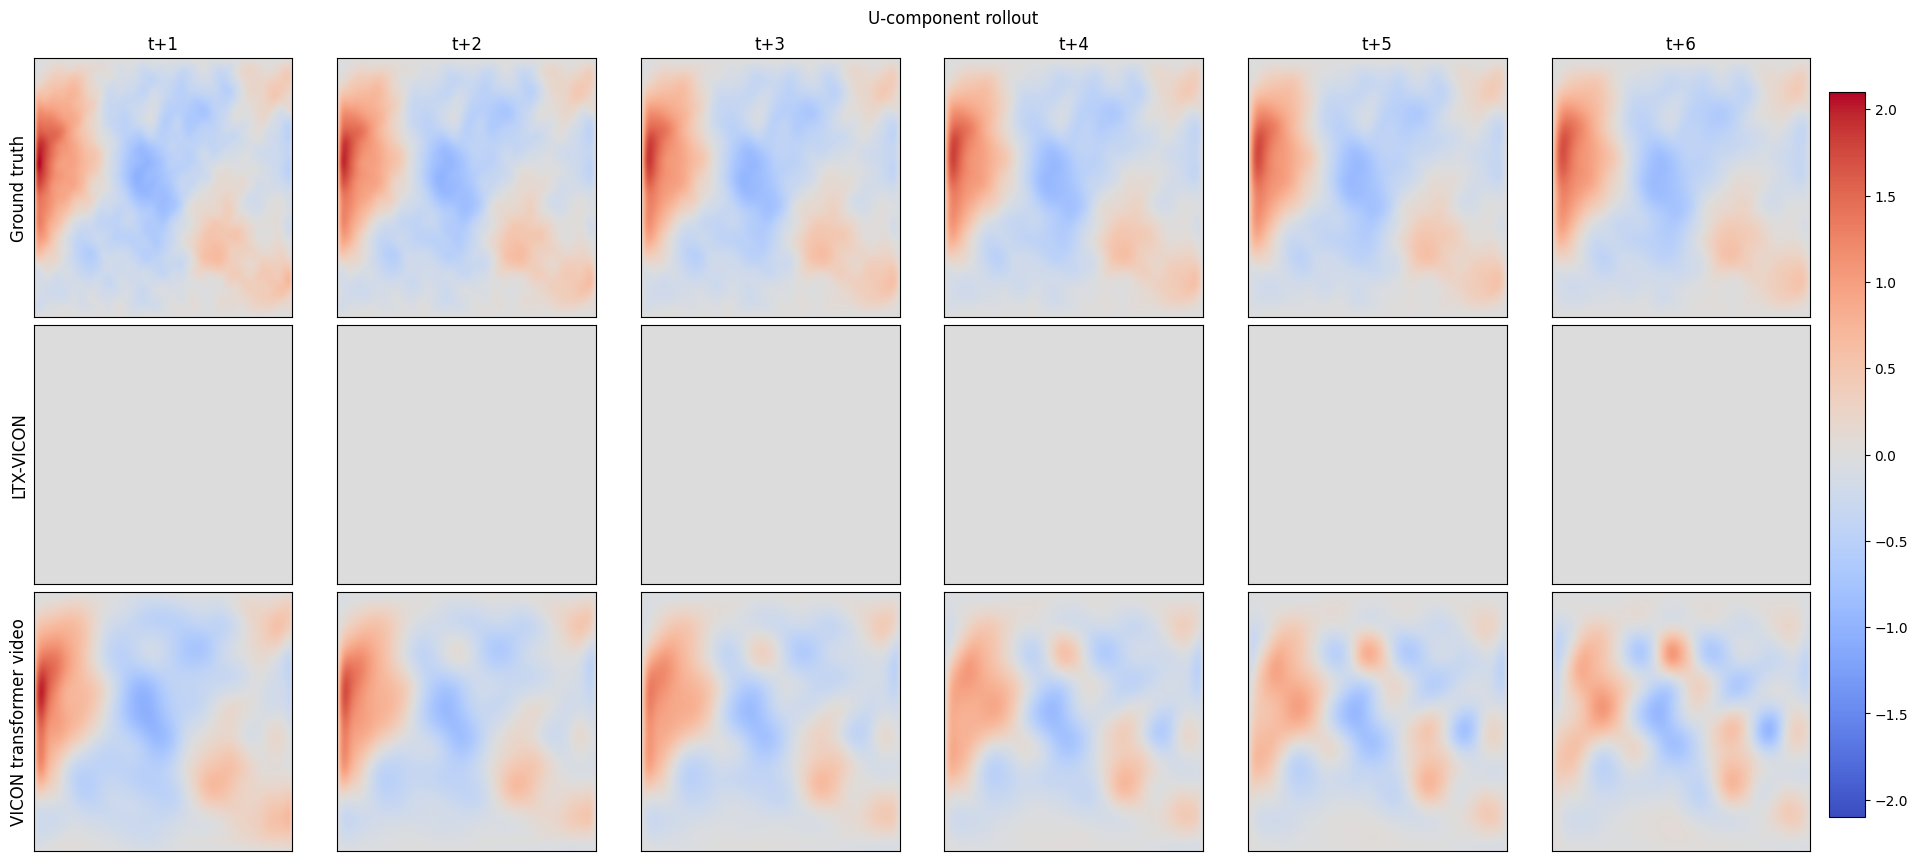

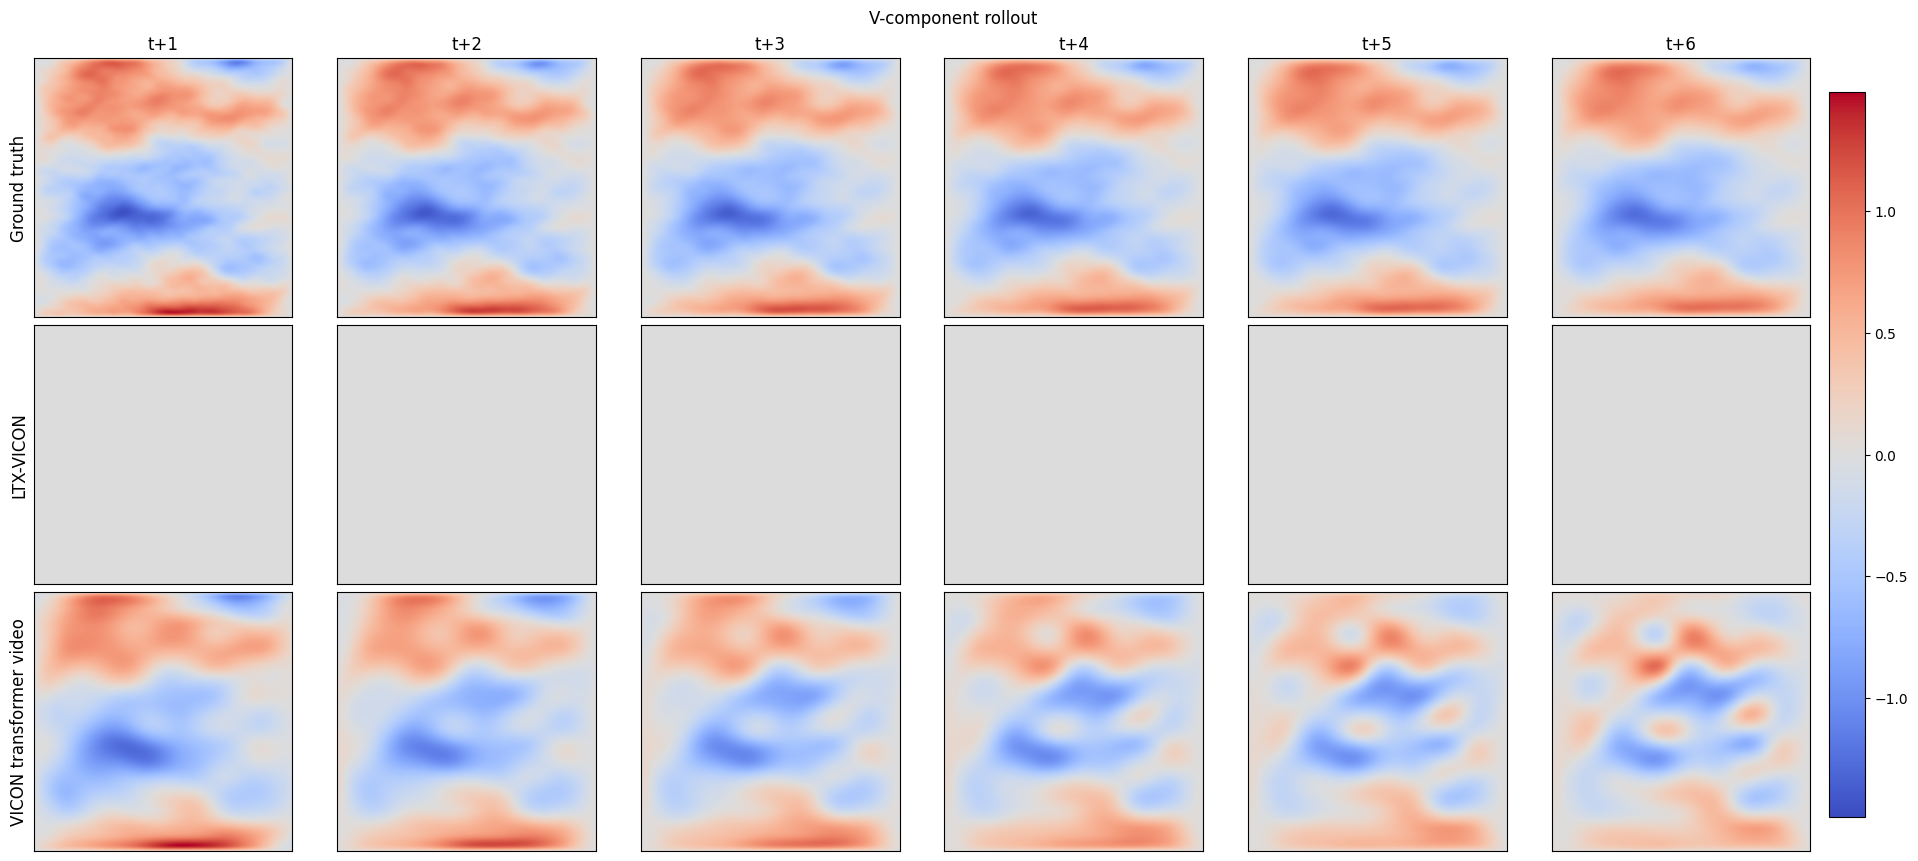

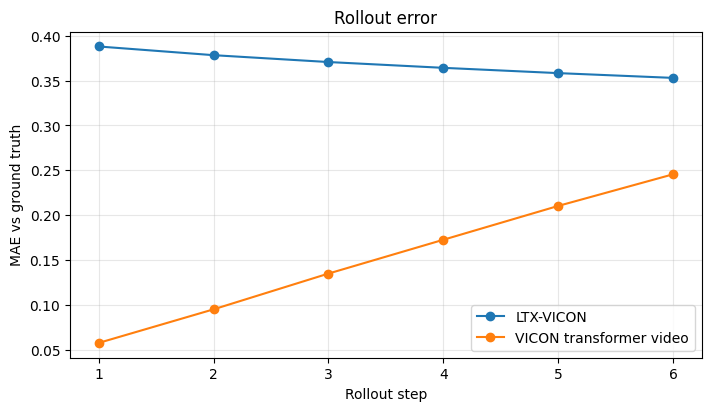

In [9]:
def plot_rollout_component(rollout_rows, component_idx, title, cmap, symmetric=False):
    component_rows = [
        (row_name, [field_maps(frame)[component_idx] for frame in row_frames])
        for row_name, row_frames in rollout_rows
    ]
    component_stack = torch.stack([component for _, row in component_rows for component in row])

    if symmetric:
        vmax = component_stack.abs().max().item()
        vmin = -vmax
    else:
        vmin = 0
        vmax = component_stack.max().item()

    fig, axes = plt.subplots(
        len(component_rows),
        rollout_steps,
        figsize=(3.2 * rollout_steps, 8.5),
        constrained_layout=True,
    )
    if rollout_steps == 1:
        axes = axes[:, None]

    for row_idx, (row_name, row_components) in enumerate(component_rows):
        for col_idx, component in enumerate(row_components):
            axis = axes[row_idx, col_idx]
            handle = axis.imshow(component.numpy(), origin='lower', vmin=vmin, vmax=vmax, cmap=cmap)
            axis.set_xticks([])
            axis.set_yticks([])
            if col_idx == 0:
                axis.set_ylabel(row_name, fontsize=12)
            if row_idx == 0:
                axis.set_title(f't+{col_idx + 1}')

    fig.colorbar(handle, ax=axes.ravel().tolist(), fraction=0.02, pad=0.01)
    fig.suptitle(title)
    return fig, axes


rollout_rows = [
    ('Ground truth', gt_rollout_frames),
    ('LTX-VICON', ltx_rollout_frames),
    ('VICON transformer video', vicon_video_rollout_frames),
]

plot_rollout_component(rollout_rows, component_idx=0, title='Speed rollout', cmap='viridis')
plot_rollout_component(rollout_rows, component_idx=1, title='U-component rollout', cmap='coolwarm', symmetric=True)
plot_rollout_component(rollout_rows, component_idx=2, title='V-component rollout', cmap='coolwarm', symmetric=True)

fig, axis = plt.subplots(figsize=(7, 4), constrained_layout=True)
steps = torch.arange(1, rollout_steps + 1)
axis.plot(steps.numpy(), ltx_rollout_mae.numpy(), marker='o', label='LTX-VICON')
axis.plot(steps.numpy(), vicon_video_rollout_mae.numpy(), marker='o', label='VICON transformer video')
axis.set_xlabel('Rollout step')
axis.set_ylabel('MAE vs ground truth')
axis.set_title('Rollout error')
axis.grid(True, alpha=0.3)
axis.legend()

(<Figure size 1500x400 with 3 Axes>,
 array([<Axes: title={'center': 'Speed RRMSE'}, xlabel='Rollout step', ylabel='Relative RMSE'>,
        <Axes: title={'center': 'U-component RRMSE'}, xlabel='Rollout step', ylabel='Relative RMSE'>,
        <Axes: title={'center': 'V-component RRMSE'}, xlabel='Rollout step', ylabel='Relative RMSE'>],
       dtype=object))

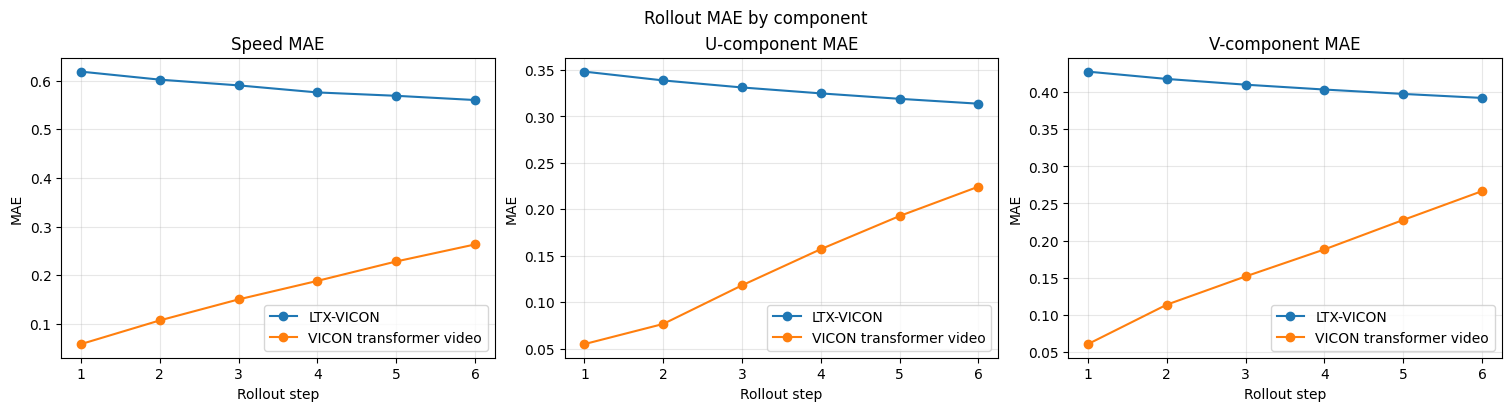

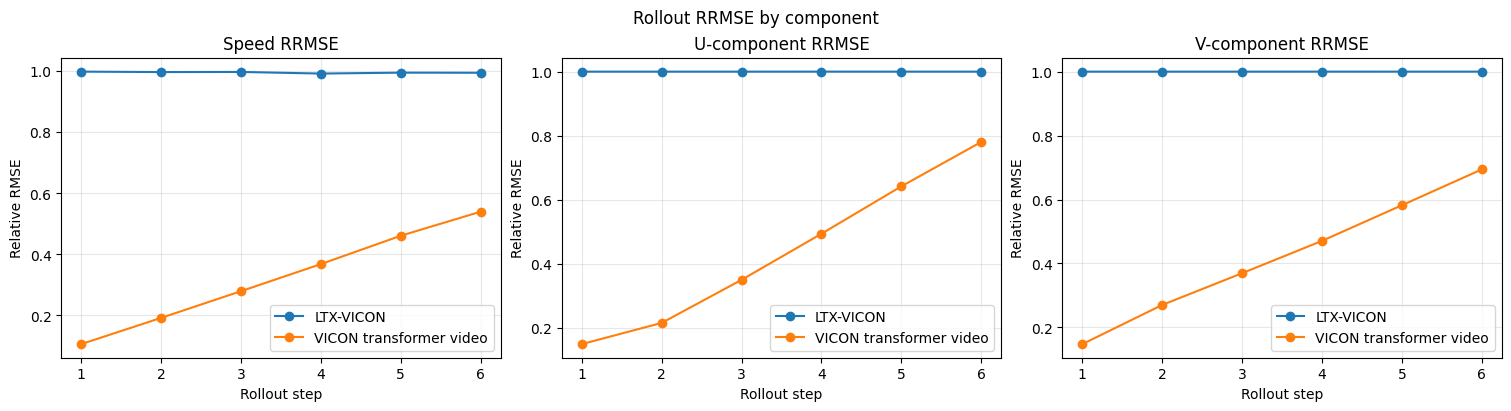

In [10]:
def collect_component_metric(frames, targets, metric_fn):
    values = [metric_fn(pred, target) for pred, target in zip(frames, targets, strict=True)]
    return [torch.tensor([triple[idx].item() for triple in values]) for idx in range(3)]

ltx_speed_mae, ltx_u_mae, ltx_v_mae = collect_component_metric(
    ltx_rollout_frames, gt_rollout_frames, component_maes
)
vicon_speed_mae, vicon_u_mae, vicon_v_mae = collect_component_metric(
    vicon_video_rollout_frames, gt_rollout_frames, component_maes
)

ltx_speed_rrmse, ltx_u_rrmse, ltx_v_rrmse = collect_component_metric(
    ltx_rollout_frames, gt_rollout_frames, component_rrmses
)
vicon_speed_rrmse, vicon_u_rrmse, vicon_v_rrmse = collect_component_metric(
    vicon_video_rollout_frames, gt_rollout_frames, component_rrmses
)


def plot_component_curves(metric_name, ylabel, ltx_values, vicon_values):
    labels = ['Speed', 'U-component', 'V-component']
    fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
    for axis, label, ltx_value, vicon_value in zip(axes, labels, ltx_values, vicon_values, strict=True):
        axis.plot(steps.numpy(), ltx_value.numpy(), marker='o', label='LTX-VICON')
        axis.plot(steps.numpy(), vicon_value.numpy(), marker='o', label='VICON transformer video')
        axis.set_title(f'{label} {metric_name}')
        axis.set_xlabel('Rollout step')
        axis.set_ylabel(ylabel)
        axis.grid(True, alpha=0.3)
        axis.legend()
    fig.suptitle(f'Rollout {metric_name} by component')
    return fig, axes

plot_component_curves(
    'MAE',
    'MAE',
    [ltx_speed_mae, ltx_u_mae, ltx_v_mae],
    [vicon_speed_mae, vicon_u_mae, vicon_v_mae],
)
plot_component_curves(
    'RRMSE',
    'Relative RMSE',
    [ltx_speed_rrmse, ltx_u_rrmse, ltx_v_rrmse],
    [vicon_speed_rrmse, vicon_u_rrmse, vicon_v_rrmse],
)